In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder

In [2]:
df= pd.read_csv("heart.csv")

In [4]:
df.sample(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
527,61,M,ATA,139,283,0,Normal,135,N,0.3,Up,0
799,53,M,NAP,130,246,1,LVH,173,N,0.0,Up,0
872,55,M,ASY,132,353,0,Normal,132,Y,1.2,Flat,1
90,49,F,ATA,110,208,0,Normal,160,N,0.0,Up,0
309,57,M,ASY,95,0,1,Normal,182,N,0.7,Down,1
84,56,M,ASY,150,213,1,Normal,125,Y,1.0,Flat,1
601,61,M,NAP,140,284,0,Normal,123,Y,1.3,Flat,1
828,58,M,ASY,128,216,0,LVH,131,Y,2.2,Flat,1
885,53,F,NAP,128,216,0,LVH,115,N,0.0,Up,0
83,52,M,ATA,160,196,0,Normal,165,N,0.0,Up,0


In [5]:
df.shape

(918, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [10]:
df["ST_Slope"].value_counts()

ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

### we can just now do onehot encoding on st_splore

In [11]:
df["ChestPainType"].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

#### again similar we can just apply one hot here too


<Axes: xlabel='Oldpeak', ylabel='Count'>

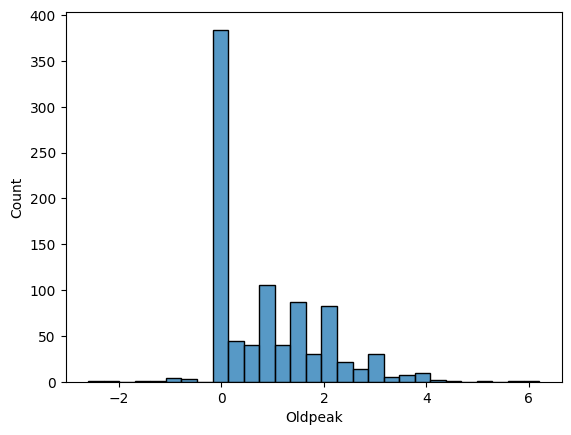

In [17]:
sns.histplot(df["Oldpeak"])

In [19]:
df["ExerciseAngina"].value_counts()

ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

In [20]:
df["RestingECG"].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

In [24]:
x=df.drop(columns=["HeartDisease"])
y=df["HeartDisease"]

In [25]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3)

In [28]:
ohe=OneHotEncoder(drop='first', sparse_output=False,handle_unknown='ignore')

In [47]:
categorical_cols = x_train.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_cols = x_train.select_dtypes(exclude=['object', 'category']).columns.tolist()
categorical_cols,numerical_cols

(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'],
 ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'])

In [48]:
x_train_ohe =ohe.fit_transform(x_train[categorical_cols])
x_test_ohe=ohe.transform(x_test[categorical_cols])

In [36]:
x_train_ohe

array([[0., 0., 1., ..., 0., 0., 1.],
       [1., 0., 0., ..., 1., 1., 0.],
       [1., 0., 0., ..., 0., 0., 1.],
       ...,
       [1., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 1., 0.],
       [1., 1., 0., ..., 0., 0., 1.]], shape=(642, 9))

In [53]:
x_train_trf = np.concat([x_train_ohe,x_train[numerical_cols]],axis=1)
x_test_trf = np.concat([x_test_ohe,x_test[numerical_cols]],axis=1)

In [ ]:
pd.DataFrame(x_)

array([[  0. ,   0. ,   1. , ...,   0. , 163. ,   0. ],
       [  1. ,   0. ,   0. , ...,   1. , 126. ,   1.1],
       [  1. ,   0. ,   0. , ...,   0. , 150. ,   0. ],
       ...,
       [  1. ,   1. ,   0. , ...,   0. , 120. ,   0.7],
       [  0. ,   0. ,   0. , ...,   0. , 123. ,   0.2],
       [  1. ,   1. ,   0. , ...,   0. , 171. ,   0.6]], shape=(642, 15))

In [120]:
re=RandomForestClassifier(n_estimators=200,max_samples=0.7,random_state=2)

In [121]:
re.fit(x_train_trf,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [122]:
y_pred=re.predict(x_test_trf)

In [123]:
from sklearn.metrics import accuracy_score
accuracy_score(y_pred,y_test)

0.8804347826086957